# Varible Energy Positron Annihilation Spectroscopy Experimental Data Analysis Example
This notebook contains example on how to use pyPAS in order to do VEPDB on measured adta\
The sample measured is Cu sample which was annealed 10 hours on 500 degrees Celsius

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

from scipy.constants import nano, centi, pico

import matplotlib.pyplot as plt

from pyPAS.positron_implantation_profile import makhov_material_parameters, makhov_profile, multilayer_implantation_profile
from pyPAS.positron_annihilation_profile import profile_solver, annihilation_fraction_per_layer
from pyPAS.sample import Layer, Material, Sample
from pyPAS.vedb import OneBulkDiffusionLengthOptimization

from pyspectrum import germanium_fwhm

import dask
from dask.diagnostics import ProgressBar

from itertools import product

from uncertainties import nominal_value, std_dev, ufloat, unumpy
from uncertainties.unumpy import uarray, nominal_values, std_devs
import matplotlib
import scienceplots

plt.style.use('science')
matplotlib.rcParams['text.usetex'] = False


# Load Experimental data 

In [2]:
ds = xr.load_dataset('../libs/cu_sample_500/lineshape_new.nc')
s_parm_measurement = unumpy.uarray(ds['nominal'].values, ds['uncertainty'].values)
s_parm_measurement = xr.DataArray(s_parm_measurement, coords=ds.coords)

# One Layed SciPy Fitting

Sample Structure

In [3]:
# sample
D = 1 * (nano/centi) ** 2 / pico # normal for metals [cm**2/s]

L = 100 
L_absorb = 1 # assuming around 1 nm

λ= D/L**2

m = Material(name='Cu', diffusion=D, mobility=0, bulk_annihilation_rate=λ)
l = Layer(start=0, width=int(10e3), material=m) # practically infinite sample

initial_guess_cu_sample = Sample(layers=[l], absorbtion_length=L_absorb)

 implantation

In [4]:
data_mak = makhov_material_parameters()

Cu_parameters = data_mak.iloc[9].copy()
Cu_parameters.loc['density'] = 8.96

In [5]:
implantation_depth = np.linspace(0, initial_guess_cu_sample.sample_length(), 100000)

In [6]:
positron_implantation_profiles = []
for energy in s_parm_measurement.energy:
    positron_implantation_profiles.append(multilayer_implantation_profile(
    positron_energy=energy.item(),
    depth_vector=implantation_depth, 
    widths=[l.width],
    materials_parameters=[Cu_parameters],
    densities=[Cu_parameters.density],
    implantation_profile_function=makhov_profile     
 ))

fit

In [7]:
vedbfit = OneBulkDiffusionLengthOptimization(positron_implantation_profiles, pd.Series(s_parm_measurement.values, s_parm_measurement.energy), initial_guess_cu_sample, num_of_mesh_cells=100000)

In [8]:
min_parm = vedbfit.optimize_diffusion_length()
min_parm

{'layer_0': 132.6406207589326+/-25.794438810699845}

# Plot fit compared with measuerement

In [9]:
# define sample with fit parameters
sample = vedbfit.make_sample(nominal_value(min_parm['layer_0']))
# annihilation fraction in surface and bulk
annihilation_channel_rate_matrix = vedbfit.layers_transport_solver(sample, vedbfit.positron_implantation_profiles)
# The most likely S per layer
s_per_layer = vedbfit.s_value_per_layer(annihilation_channel_rate_matrix)

In [10]:
plt_energies = np.arange(0.5,15,0.5)

# create the implantation profiles for all of the energies
expanded_positron_implantation_profiles = [multilayer_implantation_profile(positron_energy=energy, depth_vector=implantation_depth, widths=[l.width],
                                                                             materials_parameters=[Cu_parameters], densities=[Cu_parameters.density],
                                                                             implantation_profile_function=makhov_profile) for energy in plt_energies]
expanded_annihilation_channel_rate_matrix = vedbfit.layers_transport_solver(sample, expanded_positron_implantation_profiles)
plt_s = expanded_annihilation_channel_rate_matrix@s_per_layer

(0.5130887477014897, 0.5415196323057474)

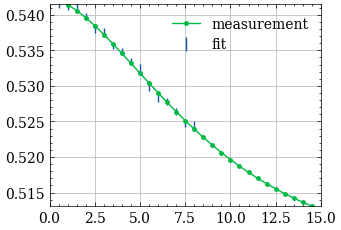

In [11]:
plt.errorbar(x=s_parm_measurement.energy, y=nominal_values(s_parm_measurement), yerr=std_devs(s_parm_measurement), ls='')
plt.plot(plt_energies, plt_s, marker='.', markersize=5)
plt.grid()
plt.legend(['measurement', 'fit'])
plt.xlim([0,15])
plt.ylim([nominal_values(plt_s).min(),nominal_values(s_parm_measurement).max()])

# Likelihood analysis

## One Layer

utils

In [12]:
@dask.delayed
def chi_squared_1l(vedbfit, l_bulk):
    # find s_sample of the fit
    sample = vedbfit.make_sample(l_bulk)
    annihilation_channel_rate_matrix = vedbfit.layers_transport_solver(sample, vedbfit.positron_implantation_profiles)
    try:
        s_vec = vedbfit.s_value_per_layer(annihilation_channel_rate_matrix)
    except:
        return np.nan

    s_sample = annihilation_channel_rate_matrix @ s_vec
    
    if s_vec[1] >= 1 or np.any(s_vec <= 0) :
        return np.nan
        
    return ((s_sample - vedbfit.s_measurement)**2/vedbfit.s_measurement_dev**2).sum()

test

In [13]:
chi_squared_1l(vedbfit, nominal_value(min_parm['layer_0'])).compute()

16.22085310662176

grid calculation

In [14]:
dlb = 5
bulk_diffusion_length = np.arange(dlb, 500+dlb, dlb)

In [15]:
# Create delayed tasks for the entire grid
lazy_chisq_list = []
lazy_residuals = []

for l_b in bulk_diffusion_length:
    lazy_chisq_list.append(chi_squared_1l(vedbfit, l_b))

In [16]:
# Compute all the results in parallel
with ProgressBar():
    persisted_chisq = dask.persist(*lazy_chisq_list)

[########################################] | 100% Completed | 86.22 s


In [17]:
chisq = np.array(dask.compute(*persisted_chisq)).reshape(len(bulk_diffusion_length))
chisq = xr.DataArray(chisq, coords={'dl':bulk_diffusion_length})

In [44]:
# Save to file
# chisq.to_netcdf("../libs/results/chisq_data_one_layer.nc")

In [45]:
# load from file
#chisq = xr.load_dataarray("./results/chisq_data_one_layer.nc")

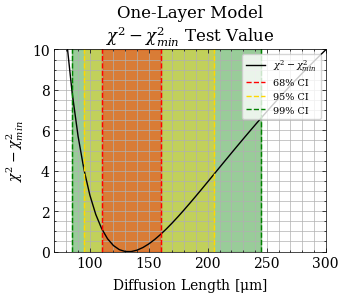

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# === 1D Chi-Square Setup ===
chisq_treshold_69 = chisq.min().item() + 0.9889
chisq_treshold_95 = chisq.min().item() + 3.84
chisq_treshold_99 = chisq.min().item() + 6.63

crossing_indices69 = np.where(np.diff(np.sign(chisq.values - chisq_treshold_69)) != 0)[0]
crossing_indices95 = np.where(np.diff(np.sign(chisq.values - chisq_treshold_95)) != 0)[0]
crossing_indices99 = np.where(np.diff(np.sign(chisq.values - chisq_treshold_99)) != 0)[0]

# Sort crossing indices and get diffusion length values
dl_vals = chisq.dl.values  # Assuming this is your x-axis coordinate array

# Extract CI boundaries (assumes 2 crossings per CI)
ci_68_bounds = dl_vals[crossing_indices69]
ci_95_bounds = dl_vals[crossing_indices95]
ci_99_bounds = dl_vals[crossing_indices99]

# Fill regions


# === Left plot: 1D Chi-Square curve with CIs ===
(chisq-chisq.min()).plot(yscale='linear', label=r'$\chi^2-\chi_{min}^2$ ', color='black')

plt.vlines(x=[chisq.dl[crossing_indices69]], ymin=0, ymax=1e2, colors='red', ls='--', label='68% CI')
plt.vlines(x=[chisq.dl[crossing_indices95]], ymin=0, ymax=1e2, colors='gold', ls='--', label='95% CI')
plt.vlines(x=[chisq.dl[crossing_indices99]], ymin=0, ymax=1e2, colors='green', ls='--', label='99% CI')

plt.xlabel(r'Diffusion Length [$\mathrm{\mu m}$]')
plt.ylabel(r'$\chi^2-\chi_{min}^2$')
plt.title('One-Layer Model\n' + r'$\chi^2-\chi_{min}^2$ Test Value')
plt.ylim([0, 10])
plt.xlim([70, 300])
plt.grid(which='both')
plt.legend(fontsize='x-small', loc='upper right', frameon=True)

# Fill regions
plt.axvspan(ci_99_bounds[0], ci_99_bounds[1], color='green', alpha=0.4, label='99% CI')
plt.axvspan(ci_95_bounds[0], ci_95_bounds[1], color='gold', alpha=0.4, label='95% CI')
plt.axvspan(ci_68_bounds[0], ci_68_bounds[1], color='red', alpha=0.4, label='68% CI')

plt.show()


In [47]:
# Get the flat index of the overall maximum
flat_idx = chisq.argmin().item()

# Convert the flat index to multi-dimensional indices
multi_idx = np.unravel_index(flat_idx, chisq.shape)

# Map the indices to coordinate labels
min_coords = {dim: chisq.coords[dim].values[idx] for dim, idx in zip(chisq.dims, multi_idx)}
min_coords

{'dl': 135}